In [1]:
import pandas as pd
import numpy as np
import os
import platform
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

# Matplotlib 한글 폰트 설정
FONT_CANDIDATES = {
    "Darwin": ["AppleGothic"],
    "Windows": ["Malgun Gothic"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}.get(platform.system(), [])

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in FONT_CANDIDATES:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
else:
    print("한글 폰트를 찾지 못했습니다. 시스템에 한글 폰트를 설치해 주세요.")

plt.rcParams["axes.unicode_minus"] = False

In [2]:
churn = pd.read_csv('../data/raw/gym_churn_1M_dataset.csv', sep=',', na_values=[''], quotechar='"')
churn

,Member_ID,Age,Gender,Membership_Type,Membership_Start_Date,Monthly_Fee,Monthly_Visits,Avg_Workout_Duration_Min,Peak_Hour_Preference,Cardio_Preference,Treadmill_Avg_Speed_Kmh,Treadmill_Avg_Incline_Pct,Group_Class_Attendance,PT_Session_Count,Supplement_Usage,Avg_Equipment_Wait_Time_Min,Late_Payment_Count,Profile_Type,Churn
0,1,17,Male,Premium,2025-08-20,74.61,10,76,Evening (17-21),Cycling,NaN,NaN,5,0,NaN,16.7,5,Casual,1
1,2,57,Male,Premium,2023-10-18,73.89,3,40,Evening (17-21),Treadmill,13.9,3.2,12,0,Full Stack,9.7,0,Drop-out,0
2,3,26,Female,Standard,2024-08-20,27.77,12,62,Late Night (21-24),Cycling,NaN,NaN,12,0,Whey Protein,23.0,6,Regular,0
3,4,25,Male,Standard,2024-01-28,28.90,5,58,Midday (10-14),Treadmill,8.7,12.1,11,0,Whey Protein,22.3,0,Casual,0
4,5,26,Male,Gold,2025-03-21,48.41,24,40,Late Night (21-24),Rowing,NaN,NaN,3,2,Pre-Workout,22.6,2,Casual,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,55,Male,Standard,2024-11-18,29.98,10,57,Midday (10-14),Rowing,NaN,NaN,10,0,Pre-Workout,24.2,0,Casual,0
999996,999997,34,Female,Gold,2025-02-21,49.00,2,112,Evening (17-21),Cycling,NaN,NaN,0,0,NaN,12.7,2,Drop-out,0
999997,999998,18,Male,Gold,2024-02-08,49.32,18,46,Morning (6-10),Cycling,NaN,NaN,7,2,NaN,15.9,6,Regular,1
999998,999999,21,Female,Gold,2025-06-01,49.63,8,54,Evening (17-21),Cycling,NaN,NaN,4,0,Whey Protein,9.6,3,Casual,0


| 컬럼명                           | 설명                | Type               |
| ----------------------------- | ----------------- |---------------- |
| `Member_ID`                   | 고유 회원 식별자         | int64 |
| `Age`                         | 고객 연령             | int64 |
| `Gender`                      | 성별 범주             | str|
| `Membership_Type`             | 헬스장 회원권 플랜        |str|
| `Membership_Start_Date`       | 멤버십 시작일           |str|
| `Monthly_Fee`                 | 월간 구독료            |float64|
| `Monthly_Visits`              | 월간 방문 횟수          |int64 |
| `Avg_Workout_Duration_Min`    | 평균 운동 시간(분)       |int64 |
| `Peak_Hour_Preference`        | 선호하는 헬스장 이용 시간    |str|
| `Cardio_Preference`           | 선호하는 유산소 운동 기구    |str|
| `Treadmill_Avg_Speed_Kmh`     | 러닝머신 평균 속도(km/h)  |float64|
| `Treadmill_Avg_Incline_Pct`   | 러닝머신 평균 경사도(%)    |float64|
| `Group_Class_Attendance`      | 그룹 수업 참여 횟수       |int64 |
| `PT_Session_Count`            | 개인 트레이너(PT) 세션 횟수 |int64 |
| `Supplement_Usage`            | 보충제 사용 여부/범주      |str|
| `Avg_Equipment_Wait_Time_Min` | 평균 장비 대기 시간(분)    |float64|
| `Late_Payment_Count`          | 연체 건수             |int64|
| `Profile_Type`                | 시뮬레이션된 고객 프로필_    |str|
|`Churn`| 이탈(0/1)|int64|


In [3]:
# 데이터 정보 확인

churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Member_ID                    1000000 non-null  int64  
 1   Age                          1000000 non-null  int64  
 2   Gender                       1000000 non-null  str    
 3   Membership_Type              1000000 non-null  str    
 4   Membership_Start_Date        1000000 non-null  str    
 5   Monthly_Fee                  1000000 non-null  float64
 6   Monthly_Visits               1000000 non-null  int64  
 7   Avg_Workout_Duration_Min     1000000 non-null  int64  
 8   Peak_Hour_Preference         1000000 non-null  str    
 9   Cardio_Preference            773315 non-null   str    
 10  Treadmill_Avg_Speed_Kmh      337598 non-null   float64
 11  Treadmill_Avg_Incline_Pct    337598 non-null   float64
 12  Group_Class_Attendance       1000000 non-null  int64  

In [4]:
print(f'컬럼명:\n {churn.columns.values.tolist()}')
print(f'데이터 행: {churn.shape[0]}, 열: {churn.shape[1]}')


컬럼명:
 ['Member_ID', 'Age', 'Gender', 'Membership_Type', 'Membership_Start_Date', 'Monthly_Fee', 'Monthly_Visits', 'Avg_Workout_Duration_Min', 'Peak_Hour_Preference', 'Cardio_Preference', 'Treadmill_Avg_Speed_Kmh', 'Treadmill_Avg_Incline_Pct', 'Group_Class_Attendance', 'PT_Session_Count', 'Supplement_Usage', 'Avg_Equipment_Wait_Time_Min', 'Late_Payment_Count', 'Profile_Type', 'Churn']
데이터 행: 1000000, 열: 19


In [5]:
# 전처리 전 데이터 타입 확인

churn.dtypes.value_counts()

int64      8
str        7
float64    4
Name: count, dtype: int64

In [6]:
# 결측치 확인

churn.isna().sum()

Member_ID                           0
Age                                 0
Gender                              0
Membership_Type                     0
Membership_Start_Date               0
Monthly_Fee                         0
Monthly_Visits                      0
Avg_Workout_Duration_Min            0
Peak_Hour_Preference                0
Cardio_Preference              226685
Treadmill_Avg_Speed_Kmh        662402
Treadmill_Avg_Incline_Pct      662402
Group_Class_Attendance              0
PT_Session_Count                    0
Supplement_Usage               419573
Avg_Equipment_Wait_Time_Min         0
Late_Payment_Count                  0
Profile_Type                        0
Churn                               0
dtype: int64

In [ ]:
# 결측치 처리

# Cardio_Preference
# 유산소 운동을 선호하지 않는 회원으로 간주
churn["Cardio_Preference"] = churn["Cardio_Preference"].fillna("No Preference")

# Supplement_Usage
# 보충제를 사용하지 않는 회원으로 간주
churn["Supplement_Usage"] = churn["Supplement_Usage"].fillna("No Protein Supplements")

In [ ]:
# 멤버 고유 ID 중복 데이터 확인

churn["Member_ID"].duplicated().sum()

In [ ]:
# `Member_ID`는 고유번호이므로 분석에 의미가 적어 제거

churn = churn.drop('Member_ID', axis=1)

In [11]:
numeric_cols = churn.select_dtypes(include="number").columns

outlier_result = []

for col in numeric_cols:
    Q1 = churn[col].quantile(0.25)
    Q3 = churn[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((churn[col] < lower) | (churn[col] > upper)).sum()

    outlier_result.append({
        "Column": col,
        "Outlier_Count": count,
        "Outlier_Ratio(%)": round(count / len(churn) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_result)

outlier_df

,Column,Outlier_Count,Outlier_Ratio(%)
0,Age,58968,5.90
1,Monthly_Fee,0,0.00
2,Monthly_Visits,25120,2.51
3,Avg_Workout_Duration_Min,0,0.00
4,Treadmill_Avg_Speed_Kmh,0,0.00
5,Treadmill_Avg_Incline_Pct,0,0.00
6,Group_Class_Attendance,0,0.00
7,PT_Session_Count,241998,24.20
8,Avg_Equipment_Wait_Time_Min,0,0.00
9,Late_Payment_Count,0,0.00


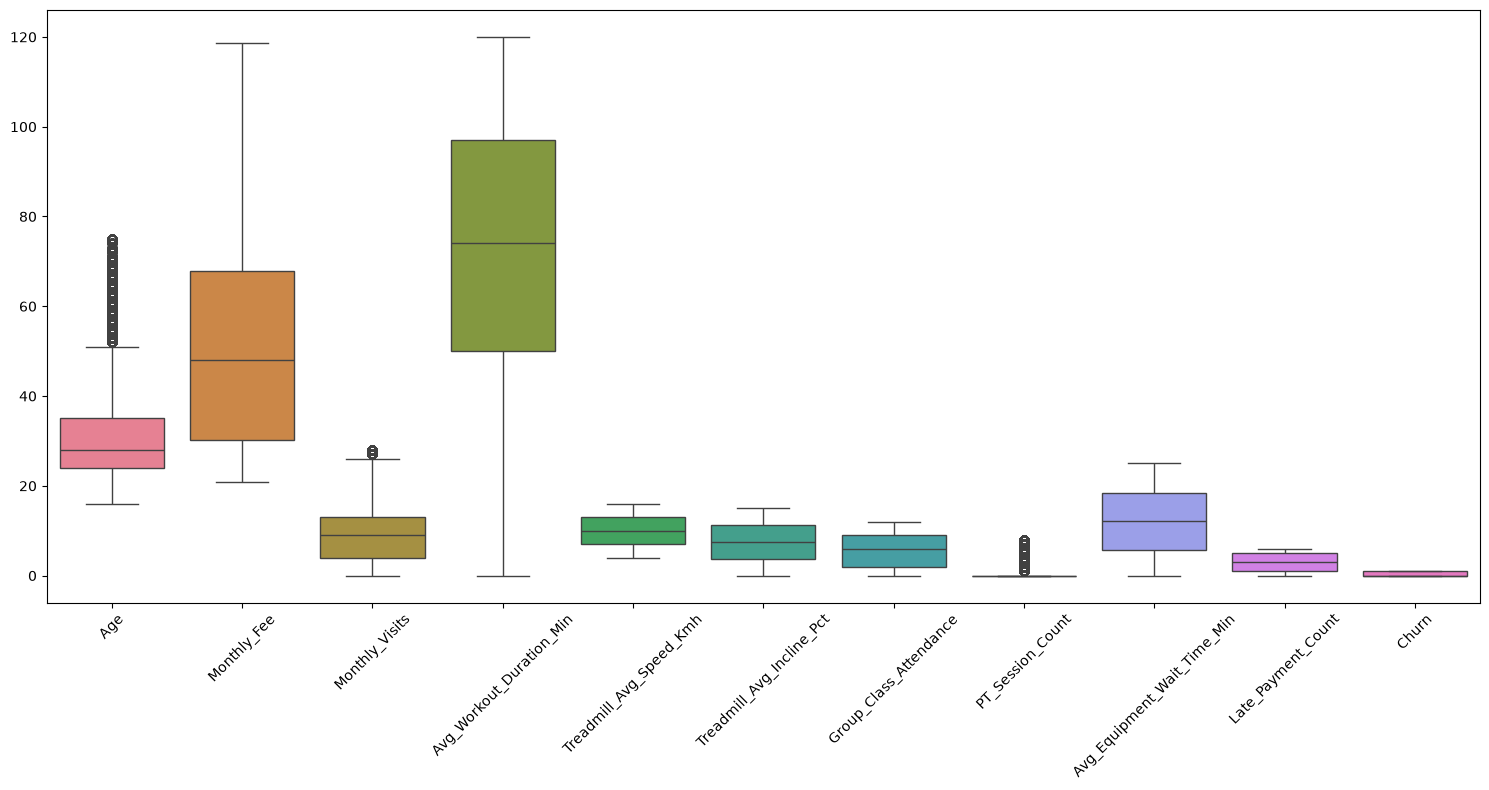

In [12]:
# boxplot 저장

save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = churn.select_dtypes(include="number").columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=churn[numeric_cols])

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, "boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

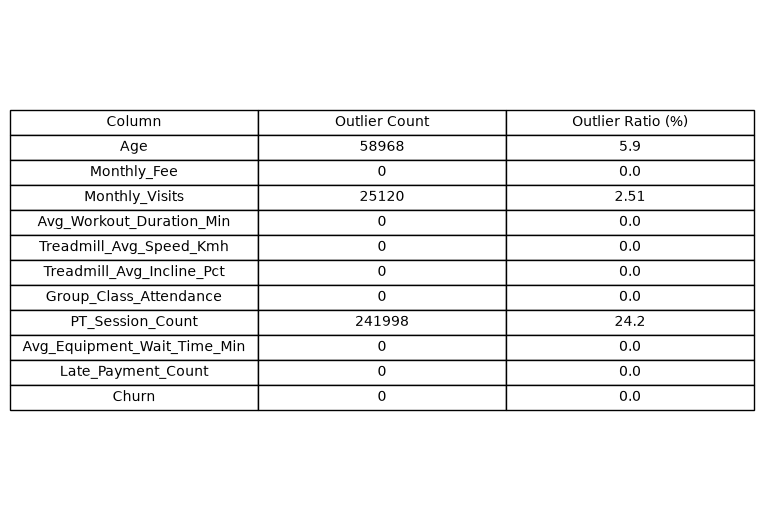

In [13]:
# IQR 결과(이미지) 저장

save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = churn.select_dtypes(include="number").columns

result = []

for col in numeric_cols:
    Q1 = churn[col].quantile(0.25)
    Q3 = churn[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((churn[col] < lower) | (churn[col] > upper)).sum()

    result.append([
        col,
        outlier_count,
        round(outlier_count / len(churn) * 100, 2)
    ])

iqr_df = pd.DataFrame(
    result,
    columns=["Column", "Outlier Count", "Outlier Ratio (%)"]
)

fig, ax = plt.subplots(figsize=(8, len(iqr_df) * 0.5 + 1))
ax.axis("off")

table = ax.table(
    cellText=iqr_df.values,
    colLabels=iqr_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig(
    os.path.join(save_dir, "iqr_result.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# None 값이 3분의 2 이상이며 중앙값으로 대체로 인한 이상치가 30퍼 이상이 나오므로 제거

churn = churn.drop('Treadmill_Avg_Speed_Kmh', axis=1)
churn = churn.drop('Treadmill_Avg_Incline_Pct', axis=1)

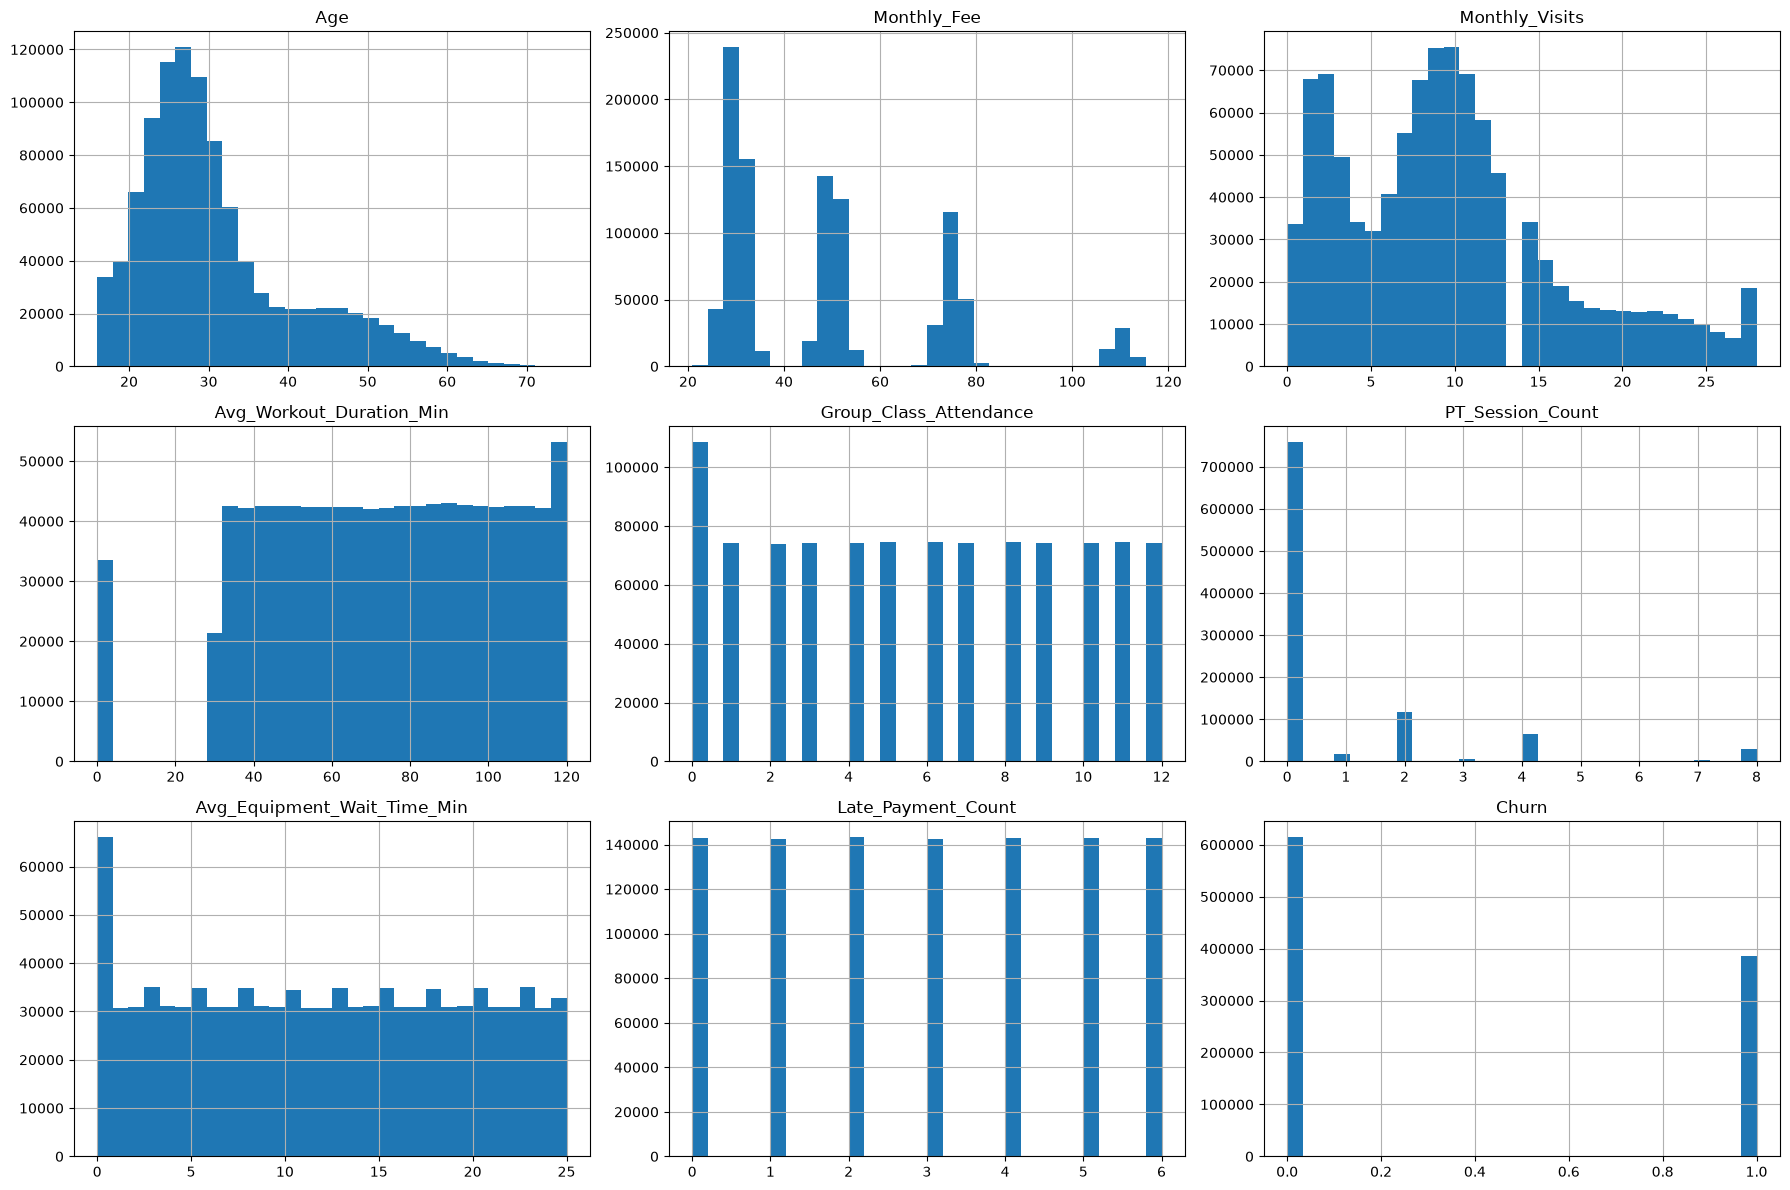

In [15]:
# 수치형 데이터 컬럼 선택
# 예: Age, Monthly_Fee, Monthly_Visits 등
numeric_cols = churn.select_dtypes(include="number").columns

# 각 수치형 변수의 분포 확인
# bins : 히스토그램 구간 개수
churn[numeric_cols].hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()
plt.show()

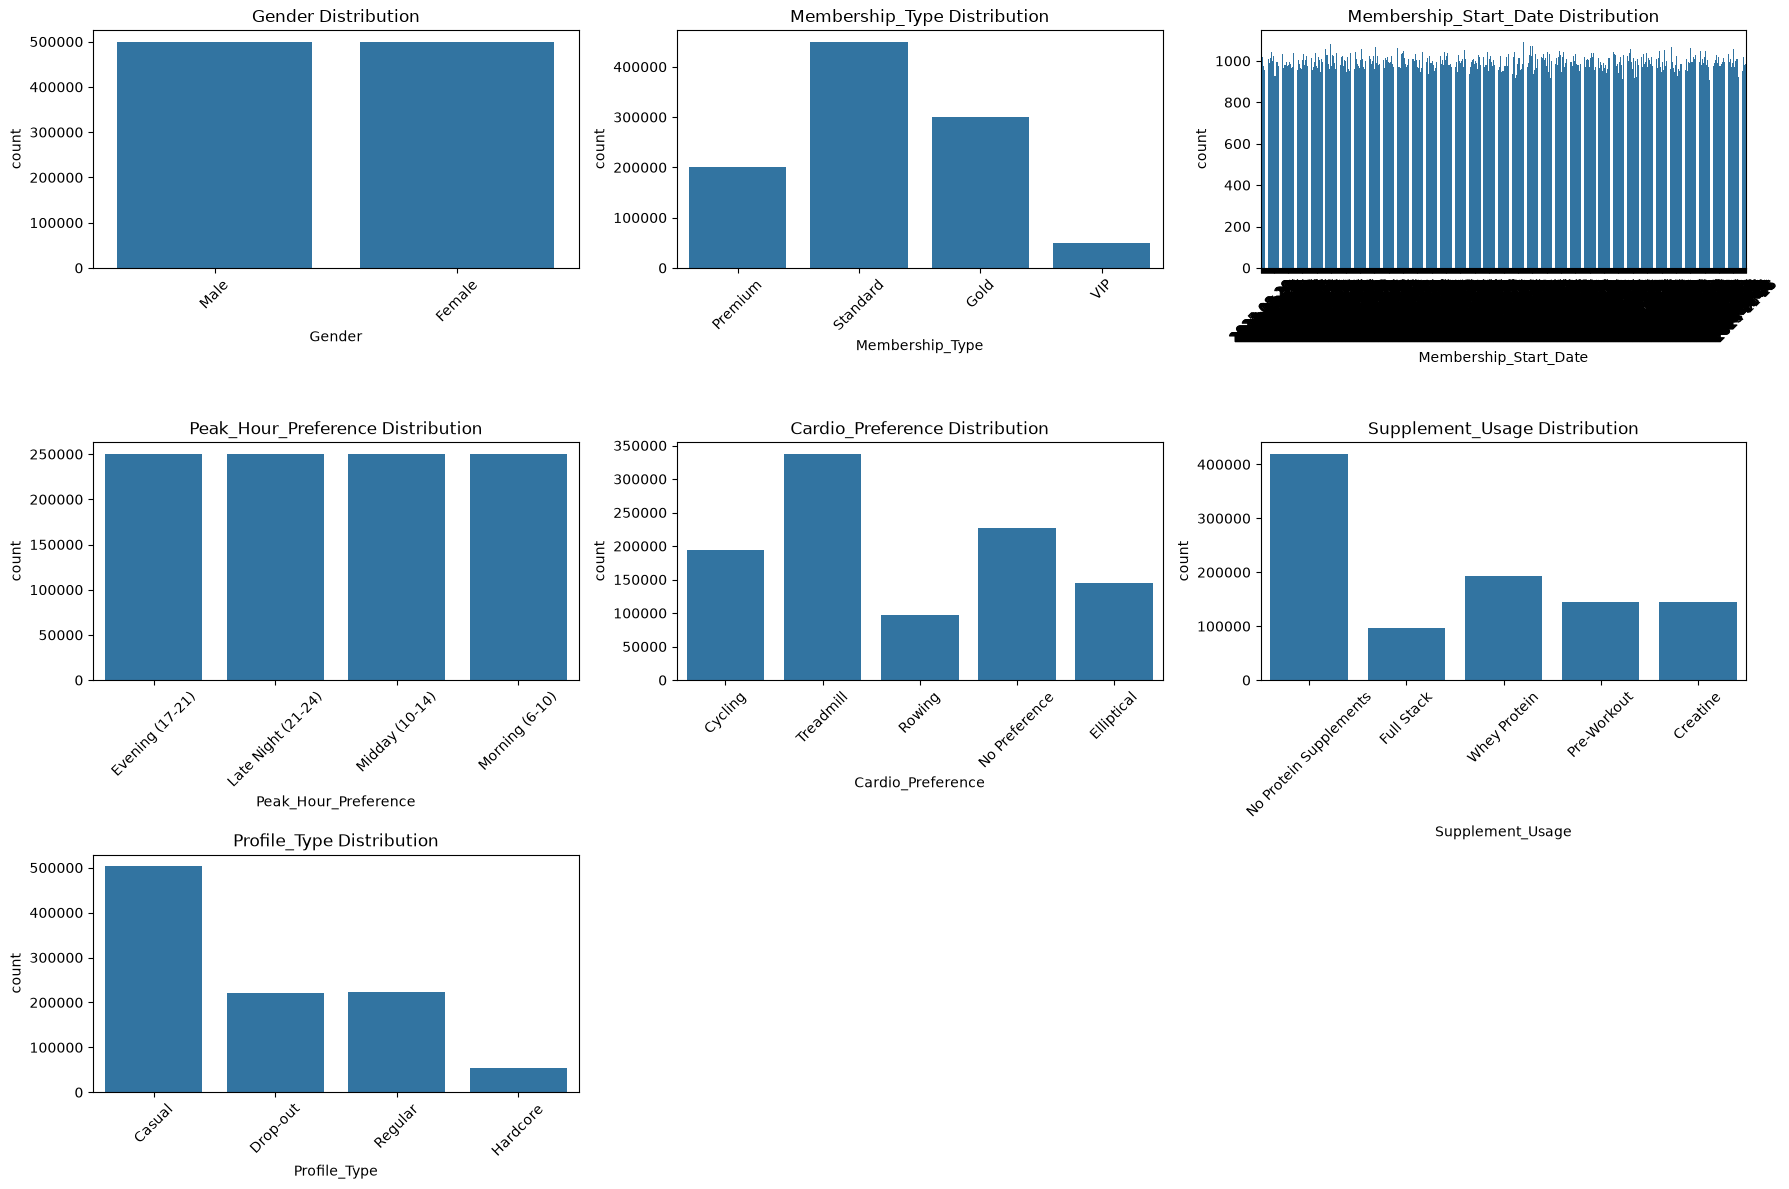

In [16]:
# 범주형 데이터 컬럼 선택
categorical_cols = churn.select_dtypes(include="str").columns

# 서브플롯 그리드 크기 계산 (한 줄에 3개씩)
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()  # 2차원 배열을 1차원으로 펼쳐서 인덱싱 편하게

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=churn,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=45)

# 남는 빈 서브플롯 숨기기
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [17]:
# 저장 폴더 생성 (없으면 자동 생성)
save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

# 수치형 데이터 컬럼 선택
numeric_cols = churn.select_dtypes(include="number").columns

# 각 수치형 변수의 분포 확인
churn[numeric_cols].hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()

# 이미지 저장
plt.savefig(os.path.join(save_dir, "numeric_distribution.png"), dpi=150)

# 플롯 표시하지 않고 닫기 (메모리 정리)
plt.close()

In [18]:
# 저장 폴더 생성 (없으면 자동 생성)
save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

# 범주형 데이터 컬럼 선택
categorical_cols = churn.select_dtypes(include="str").columns

# 서브플롯 그리드 크기 계산 (한 줄에 3개씩)
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()  # 2차원 배열을 1차원으로 펼쳐서 인덱싱 편하게

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=churn,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=45)

# 남는 빈 서브플롯 숨기기
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

# 이미지 저장
plt.savefig(os.path.join(save_dir, "categorical_distribution.png"), dpi=150)

# 플롯 표시하지 않고 닫기
plt.close()

In [19]:
# 수치형 / 범주형 컬럼 구분
numeric_cols = churn.select_dtypes(include="number").columns
categorical_cols = churn.select_dtypes(include="str").columns

print("=" * 60)
print(f"[수치형 컬럼] 총 {len(numeric_cols)}개")
print("=" * 60)
for col in numeric_cols:
    print(f"- {col} : {churn[col].count()}개 (결측치 제외)")

print("\n" + "=" * 60)
print(f"[범주형 컬럼] 총 {len(categorical_cols)}개")
print("=" * 60)
for col in categorical_cols:
    print(f"\n▶ {col} (고유값 {churn[col].nunique()}개)")
    print(churn[col].value_counts())

[수치형 컬럼] 총 9개
- Age : 1000000개 (결측치 제외)
- Monthly_Fee : 1000000개 (결측치 제외)
- Monthly_Visits : 1000000개 (결측치 제외)
- Avg_Workout_Duration_Min : 1000000개 (결측치 제외)
- Group_Class_Attendance : 1000000개 (결측치 제외)
- PT_Session_Count : 1000000개 (결측치 제외)
- Avg_Equipment_Wait_Time_Min : 1000000개 (결측치 제외)
- Late_Payment_Count : 1000000개 (결측치 제외)
- Churn : 1000000개 (결측치 제외)

[범주형 컬럼] 총 7개

▶ Gender (고유값 2개)
Gender
Female    500002
Male      499998
Name: count, dtype: int64

▶ Membership_Type (고유값 4개)
Membership_Type
Standard    449978
Gold        299987
Premium     200370
VIP          49665
Name: count, dtype: int64

▶ Membership_Start_Date (고유값 1005개)
Membership_Start_Date
2024-02-03    1093
2025-11-30    1091
2025-09-09    1080
2023-10-17    1080
2025-08-12    1079
              ... 
2023-06-13     916
2025-04-24     915
2024-07-15     915
2024-06-03     906
2025-01-24     904
Name: count, Length: 1005, dtype: int64

▶ Peak_Hour_Preference (고유값 4개)
Peak_Hour_Preference
Midday (10-14)        250332
L

In [20]:
# Churn과 각 범주형 변수 간 교차분석 (이탈률 기준)
categorical_cols = churn.select_dtypes(include="str").columns
# 날짜 컬럼은 카테고리 분석에서 제외
categorical_cols = [c for c in categorical_cols if c != "Membership_Start_Date"]

for col in categorical_cols:
    print("=" * 60)
    print(f"▶ {col} 별 Churn 비율")
    print("=" * 60)

    # 각 범주별 이탈률 계산 (Churn이 0/1이라고 가정)
    churn_rate = churn.groupby(col)["Churn"].agg(["count", "mean"])
    churn_rate.columns = ["전체 인원", "이탈률"]
    churn_rate["이탈률"] = (churn_rate["이탈률"] * 100).round(2).astype(str) + "%"
    churn_rate = churn_rate.sort_values("전체 인원", ascending=False)

    print(churn_rate)
    print()

▶ Gender 별 Churn 비율
         전체 인원     이탈률
Gender                
Female  500002  38.69%
Male    499998  38.45%

▶ Membership_Type 별 Churn 비율
                  전체 인원     이탈률
Membership_Type                
Standard         449978  38.54%
Gold             299987  38.65%
Premium          200370  38.53%
VIP               49665  38.51%

▶ Peak_Hour_Preference 별 Churn 비율
                       전체 인원     이탈률
Peak_Hour_Preference                
Midday (10-14)        250332  38.67%
Late Night (21-24)    250218  38.55%
Evening (17-21)       249851  38.58%
Morning (6-10)        249599  38.49%

▶ Cardio_Preference 별 Churn 비율
                    전체 인원     이탈률
Cardio_Preference                
Treadmill          337598  37.93%
No Preference      226685  40.79%
Cycling            193756  38.06%
Elliptical         145220  37.89%
Rowing              96741  37.66%

▶ Supplement_Usage 별 Churn 비율
                         전체 인원     이탈률
Supplement_Usage                      
No Protein Supplements  419573

In [21]:
# Churn과 각 수치형 변수 간 분석 (평균 비교 + 상관계수)
numeric_cols = churn.select_dtypes(include="number").columns
numeric_cols = [c for c in numeric_cols if c != "Churn"]

for col in numeric_cols:
    print("=" * 60)
    print(f"▶ {col} 별 Churn 통계")
    print("=" * 60)

    # Churn 여부에 따른 기술통계 비교
    stats = churn.groupby("Churn")[col].agg(["mean", "median", "std", "min", "max"])
    stats.columns = ["평균", "중앙값", "표준편차", "최소", "최대"]
    stats = stats.round(2)

    print(stats)

    # Churn=1과 Churn=0 평균 차이 (%)
    mean_0 = stats.loc[0, "평균"]
    mean_1 = stats.loc[1, "평균"]
    diff_pct = round((mean_1 - mean_0) / mean_0 * 100, 2) if mean_0 != 0 else None
    print(f"\n평균 차이(Churn=1 - Churn=0): {round(mean_1 - mean_0, 2)}  ({diff_pct}%)")

    # Churn과의 상관계수
    corr = churn[[col, "Churn"]].corr().iloc[0, 1]
    print(f"Churn과의 상관계수: {round(corr, 4)}")
    print()

▶ Age 별 Churn 통계
          평균   중앙값   표준편차  최소  최대
Churn                            
0      31.06  28.0  10.29  16  75
1      30.33  28.0  10.27  16  75

평균 차이(Churn=1 - Churn=0): -0.73  (-2.35%)
Churn과의 상관계수: -0.0344

▶ Monthly_Fee 별 Churn 통계
          평균    중앙값   표준편차     최소      최대
Churn                                    
0      48.99  48.06  22.08  21.31  118.59
1      48.99  48.07  22.06  20.89  118.17

평균 차이(Churn=1 - Churn=0): 0.0  (0.0%)
Churn과의 상관계수: -0.0001

▶ Monthly_Visits 별 Churn 통계
          평균   중앙값  표준편차  최소  최대
Churn                           
0      10.42  10.0  6.78   0  28
1       8.70   8.0  6.60   0  28

평균 차이(Churn=1 - Churn=0): -1.72  (-16.51%)
Churn과의 상관계수: -0.1237

▶ Avg_Workout_Duration_Min 별 Churn 통계
          평균   중앙값   표준편차  최소   최대
Churn                             
0      73.32  74.0  28.23   0  120
1      71.17  73.0  30.49   0  120

평균 차이(Churn=1 - Churn=0): -2.15  (-2.93%)
Churn과의 상관계수: -0.0359

▶ Group_Class_Attendance 별 Churn 통계
         평균  중앙값  표

In [22]:
# 세 변수 모두 분포 자체가 균형/피라미드형으로 규칙적으로 나뉜 변수. 분포가 인위적으로 균등하게 생성된 변수일수록 Churn과의 관계도 평평하게 나타나므로 변별력이 떨어 진다 생각되어 제거

churn = churn.drop('Gender', axis=1)
churn = churn.drop('Membership_Type', axis=1)
churn = churn.drop('Peak_Hour_Preference', axis=1)

In [23]:
# Monthly_Fee는 전반적으로 이탈과 무관**하다는 결론이 수치형·범주형 모두에서 교차 확인됨.
churn = churn.drop('Monthly_Fee', axis=1)

In [24]:
# Membership_Start_Date: datetime 변환 → 파생변수 생성 → 원본 컬럼 제거

churn["Membership_Start_Date"] = pd.to_datetime(churn["Membership_Start_Date"])

# 파생변수 생성
churn["Start_Year"] = churn["Membership_Start_Date"].dt.year
churn["Start_Month"] = churn["Membership_Start_Date"].dt.month
churn["Start_Weekday"] = churn["Membership_Start_Date"].dt.weekday  # 0=월요일 ~ 6=일요일 (숫자로 바로 생성)

# 가입일로부터 경과 일수 (기준일: 데이터 내 최신 날짜)
reference_date = churn["Membership_Start_Date"].max()
churn["Membership_Days"] = (reference_date - churn["Membership_Start_Date"]).dt.days

# 원본 날짜 컬럼(str) 제거
churn = churn.drop(columns=["Membership_Start_Date"])

print(churn.shape)
print(churn.columns.tolist())
print(churn[["Start_Year", "Start_Month", "Start_Weekday", "Membership_Days"]].head())

(1000000, 15)
['Age', 'Monthly_Visits', 'Avg_Workout_Duration_Min', 'Cardio_Preference', 'Group_Class_Attendance', 'PT_Session_Count', 'Supplement_Usage', 'Avg_Equipment_Wait_Time_Min', 'Late_Payment_Count', 'Profile_Type', 'Churn', 'Start_Year', 'Start_Month', 'Start_Weekday', 'Membership_Days']
   Start_Year  Start_Month  Start_Weekday  Membership_Days
0        2025            8              2              182
1        2023           10              2              854
2        2024            8              1              547
3        2024            1              6              752
4        2025            3              4              334


In [25]:
churn = pd.get_dummies(
    churn,
    columns=["Cardio_Preference", "Supplement_Usage", "Profile_Type"],
    drop_first=True
)

print(churn.shape)
print(churn.columns.tolist())


(1000000, 23)
['Age', 'Monthly_Visits', 'Avg_Workout_Duration_Min', 'Group_Class_Attendance', 'PT_Session_Count', 'Avg_Equipment_Wait_Time_Min', 'Late_Payment_Count', 'Churn', 'Start_Year', 'Start_Month', 'Start_Weekday', 'Membership_Days', 'Cardio_Preference_Elliptical', 'Cardio_Preference_No Preference', 'Cardio_Preference_Rowing', 'Cardio_Preference_Treadmill', 'Supplement_Usage_Full Stack', 'Supplement_Usage_No Protein Supplements', 'Supplement_Usage_Pre-Workout', 'Supplement_Usage_Whey Protein', 'Profile_Type_Drop-out', 'Profile_Type_Hardcore', 'Profile_Type_Regular']


In [26]:
# StandardScaler 적용 대상
standard_cols = [
    "Age",
    "Monthly_Visits",
    "Avg_Workout_Duration_Min",
    "Group_Class_Attendance",
    "Avg_Equipment_Wait_Time_Min",
]

# RobustScaler 적용 대상 (이상치/왜도 큰 변수)
robust_cols = [
    "PT_Session_Count",
    "Late_Payment_Count",
]

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

churn[standard_cols] = standard_scaler.fit_transform(churn[standard_cols])
churn[robust_cols] = robust_scaler.fit_transform(churn[robust_cols])

print(churn[standard_cols + robust_cols].describe())

                Age  Monthly_Visits  Avg_Workout_Duration_Min  \
count  1.000000e+06    1.000000e+06              1.000000e+06   
mean  -1.056719e-16    9.868018e-17             -1.685407e-16   
std    1.000001e+00    1.000001e+00              1.000001e+00   
min   -1.436819e+00   -1.443504e+00             -2.487490e+00   
25%   -6.591148e-01   -8.517971e-01             -7.718340e-01   
50%   -2.702626e-01   -1.121635e-01              5.168084e-02   
75%    4.102286e-01    4.795434e-01              8.408826e-01   
max    4.298750e+00    2.698444e+00              1.630084e+00   

       Group_Class_Attendance  Avg_Equipment_Wait_Time_Min  PT_Session_Count  \
count            1.000000e+06                 1.000000e+06    1000000.000000   
mean            -1.235776e-16                 2.353318e-16          0.812290   
std              1.000001e+00                 1.000001e+00          1.766339   
min             -1.512053e+00                -1.624177e+00          0.000000   
25%           

In [27]:
churn.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   Age                                      1000000 non-null  float64
 1   Monthly_Visits                           1000000 non-null  float64
 2   Avg_Workout_Duration_Min                 1000000 non-null  float64
 3   Group_Class_Attendance                   1000000 non-null  float64
 4   PT_Session_Count                         1000000 non-null  float64
 5   Avg_Equipment_Wait_Time_Min              1000000 non-null  float64
 6   Late_Payment_Count                       1000000 non-null  float64
 7   Churn                                    1000000 non-null  int64  
 8   Start_Year                               1000000 non-null  int32  
 9   Start_Month                              1000000 non-null  int32  
 10  Start_Weekday                 

In [28]:
#전처리 후 데이터 타입 변화 확인

churn.dtypes.value_counts()

bool       11
float64     7
int32       3
int64       2
Name: count, dtype: int64

In [29]:
#전처리 후 데이터 타입 행과 열 확인

print(f'컬럼명:\n {churn.columns.values.tolist()}')
print(f'데이터 행: {churn.shape[0]}, 열: {churn.shape[1]}')


컬럼명:
 ['Age', 'Monthly_Visits', 'Avg_Workout_Duration_Min', 'Group_Class_Attendance', 'PT_Session_Count', 'Avg_Equipment_Wait_Time_Min', 'Late_Payment_Count', 'Churn', 'Start_Year', 'Start_Month', 'Start_Weekday', 'Membership_Days', 'Cardio_Preference_Elliptical', 'Cardio_Preference_No Preference', 'Cardio_Preference_Rowing', 'Cardio_Preference_Treadmill', 'Supplement_Usage_Full Stack', 'Supplement_Usage_No Protein Supplements', 'Supplement_Usage_Pre-Workout', 'Supplement_Usage_Whey Protein', 'Profile_Type_Drop-out', 'Profile_Type_Hardcore', 'Profile_Type_Regular']
데이터 행: 1000000, 열: 23


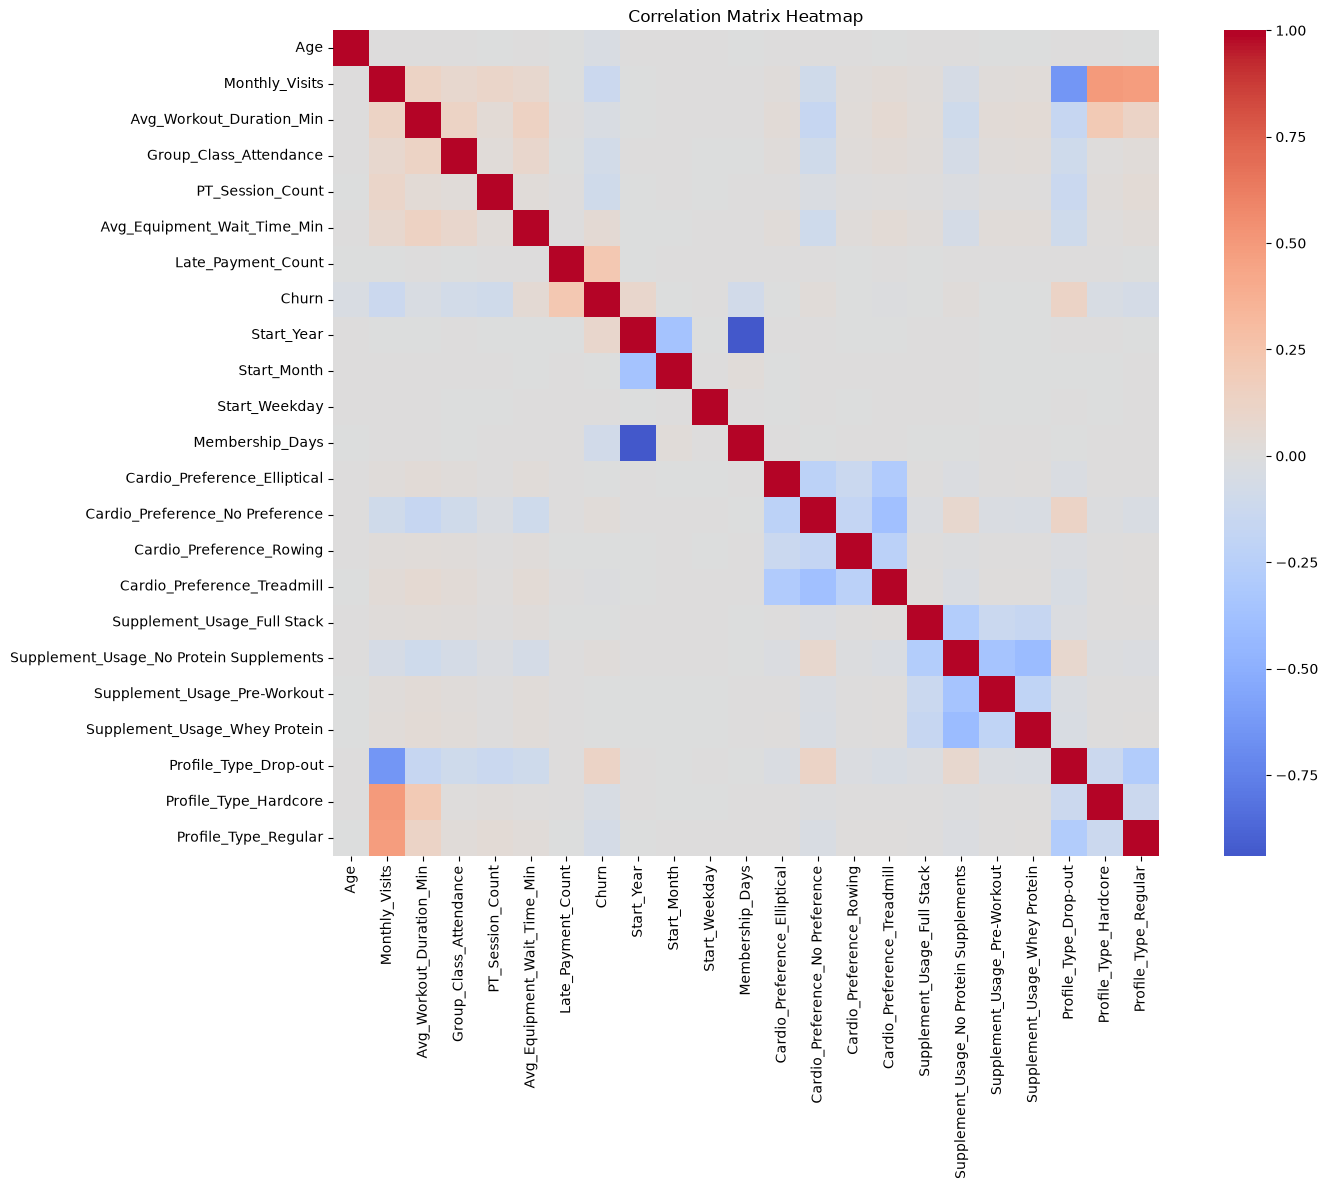

Churn과의 상관계수 (절댓값 기준 내림차순)
Late_Payment_Count                         0.224492
Monthly_Visits                            -0.123658
Profile_Type_Drop-out                      0.120997
PT_Session_Count                          -0.094206
Membership_Days                           -0.089881
Start_Year                                 0.083935
Group_Class_Attendance                    -0.078448
Profile_Type_Regular                      -0.062380
Avg_Equipment_Wait_Time_Min                0.052618
Profile_Type_Hardcore                     -0.040309
Avg_Workout_Duration_Min                  -0.035897
Age                                       -0.034406
Cardio_Preference_No Preference            0.024672
Supplement_Usage_No Protein Supplements    0.017384
Cardio_Preference_Treadmill               -0.009376
Supplement_Usage_Pre-Workout              -0.006400
Supplement_Usage_Whey Protein             -0.006171
Cardio_Preference_Rowing                  -0.006152
Cardio_Preference_Elliptical         

In [30]:
# 저장 폴더 생성 (없으면 자동 생성)
save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

# Correlation Matrix 계산 (수치형 + One-Hot 인코딩된 컬럼 전부 포함)
corr_matrix = churn.corr(numeric_only=True)

# Heatmap 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()

# 이미지 저장
plt.savefig(os.path.join(save_dir, "correlation_heatmap.png"), dpi=150)

plt.show()

# Churn과의 상관계수만 정렬해서 표로 확인
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("=" * 60)
print("Churn과의 상관계수 (절댓값 기준 내림차순)")
print("=" * 60)
print(churn_corr)

Churn 클래스 분포
Churn
0    614298
1    385702
Name: count, dtype: int64

Churn
0    61.43%
1    38.57%
Name: proportion, dtype: str


C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\1802814220.py:22: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\1802814220.py:22: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\1802814220.py:22: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\1802814220.py:22: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\1802814220.py:25: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(save_dir, "churn_class_distribution.png"), dpi=150)
C:\Users\playdata2\AppData\Local\Temp\ipykernel_41632\

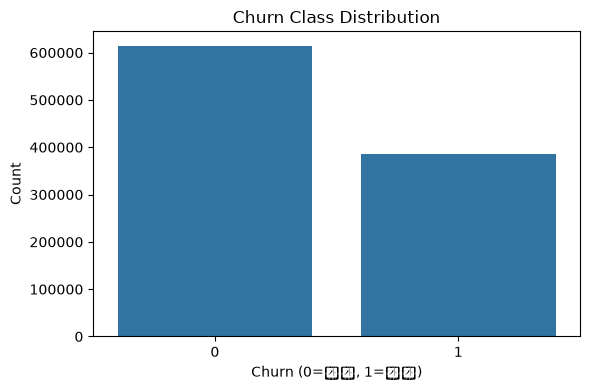


클래스 불균형 비율 (다수:소수) = 1.59 : 1


In [31]:
# 저장 폴더 생성 (없으면 자동 생성)
save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

# 클래스 분포
churn_counts = churn["Churn"].value_counts()
churn_ratio = churn["Churn"].value_counts(normalize=True) * 100

print("=" * 60)
print("Churn 클래스 분포")
print("=" * 60)
print(churn_counts)
print()
print(churn_ratio.round(2).astype(str) + "%")

# 클래스 불균형 여부 시각화
plt.figure(figsize=(6, 4))
sns.countplot(data=churn, x="Churn")
plt.title("Churn Class Distribution")
plt.xlabel("Churn (0=잔존, 1=이탈)")
plt.ylabel("Count")
plt.tight_layout()

# 이미지 저장
plt.savefig(os.path.join(save_dir, "churn_class_distribution.png"), dpi=150)

plt.show()

# 불균형 비율 확인
imbalance_ratio = churn_counts.max() / churn_counts.min()
print(f"\n클래스 불균형 비율 (다수:소수) = {imbalance_ratio:.2f} : 1")

                                    Feature  Importance
0                        Late_Payment_Count    0.512829
1                            Monthly_Visits    0.110750
2                          PT_Session_Count    0.079826
3                                Start_Year    0.078136
4                           Membership_Days    0.036392
5                    Group_Class_Attendance    0.036244
6               Avg_Equipment_Wait_Time_Min    0.034713
7                                       Age    0.020067
8   Supplement_Usage_No Protein Supplements    0.007447
9                  Cardio_Preference_Rowing    0.007387
10                 Avg_Workout_Duration_Min    0.007340
11             Supplement_Usage_Pre-Workout    0.007103
12              Supplement_Usage_Full Stack    0.006984
13          Cardio_Preference_No Preference    0.006935
14                              Start_Month    0.006935
15                     Profile_Type_Regular    0.006909
16                    Profile_Type_Hardcore    0

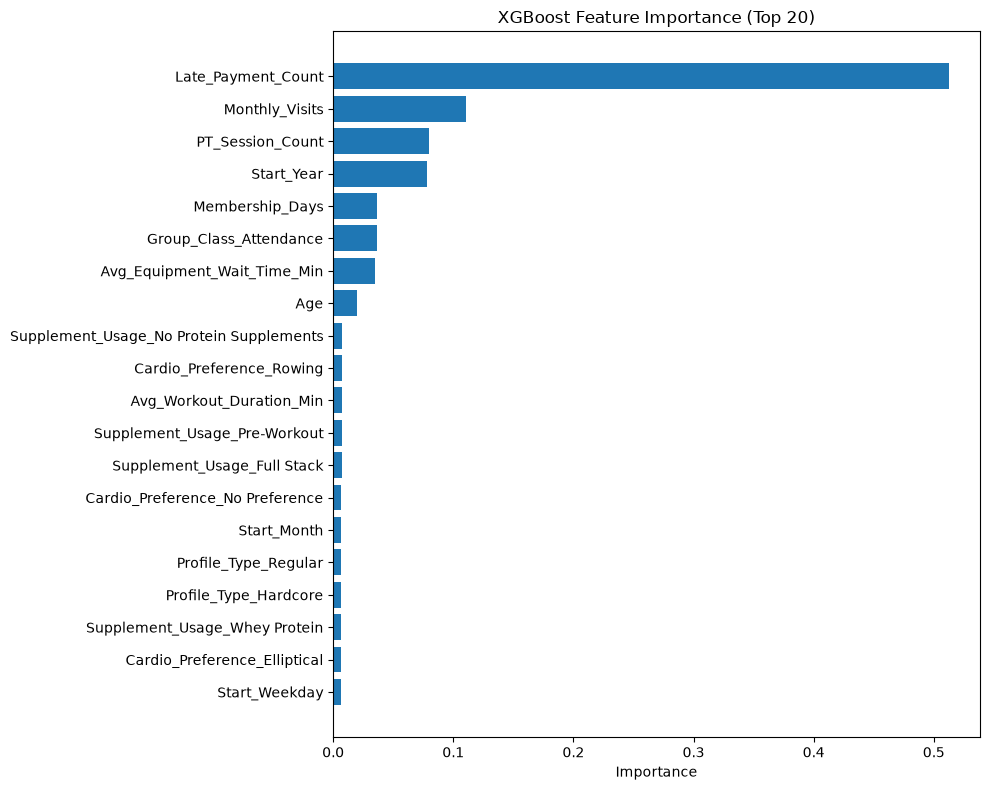

In [32]:

# Feature / Target 분리
X = churn.drop(columns=["Churn"])
y = churn["Churn"]

# Train/Test 분리 (Feature Importance 확인용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost 모델 학습
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Feature Importance 추출
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(importance_df)

# 시각화
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"][:20][::-1], importance_df["Importance"][:20][::-1])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

In [ ]:
# 중요도 기준 상위 50% 컬럼만 선택
n_features = len(importance_df)
top_n = n_features // 2  # 상위 50%

top_features = importance_df["Feature"][:top_n].tolist()

print(f"전체 Feature 수: {n_features}")
print(f"선택된 Feature 수 (상위 50%): {len(top_features)}")
print(f"선택된 Feature 목록: {top_features}")

# 선택된 Feature로 X 재구성
X_selected = X[top_features]

print(f"\n선택 후 X shape: {X_selected.shape}")
X_selected.head()